In [1]:
import pandas as pd
import numpy as np
import os
import glob
from natsort import natsorted
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy import stats

In [2]:
demographics = pd.read_csv('dataset/demographics/demographics.csv')
subcortical_atlas = pd.read_csv('dataset/demographics/atlas-subcortical.csv')
aseg = pd.read_csv('dataset/demographics/aseg.csv').iloc[:, :-1]

In [3]:
df_hurst = pd.read_csv('derivatives/Hurst_schaefer100.csv')

In [4]:
df = df_hurst[df_hurst['type']=='cross']

<ipython-input-5-95d588a1020a>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'residual_parcel_{parcel}'] = model.resid
<ipython-input-5-95d588a1020a>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'residual_parcel_{parcel}'] = model.resid
<ipython-input-5-95d588a1020a>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

Ttest_indResult(statistic=0.9789784211672721, pvalue=0.3287852739483813)
Ttest_indResult(statistic=0.9617244877314912, pvalue=0.33736102327893547)
Ttest_indResult(statistic=0.1315951825394751, pvalue=0.8954381162126831)
Ttest_indResult(statistic=0.22467456546893547, pvalue=0.8224641432202155)
Ttest_indResult(statistic=0.07896854808305737, pvalue=0.9371373911799414)
Ttest_indResult(statistic=0.782412442731423, pvalue=0.43490693166236294)
Ttest_indResult(statistic=-0.557556503931409, pvalue=0.5777770594685625)
Ttest_indResult(statistic=0.17036425826710283, pvalue=0.8648976331068161)
Ttest_indResult(statistic=0.7441541953943329, pvalue=0.45766541711615916)
Ttest_indResult(statistic=0.9518652656657397, pvalue=0.34232582443819015)
Ttest_indResult(statistic=-0.1677113744912635, pvalue=0.8669815203036637)
Ttest_indResult(statistic=0.4175334009315582, pvalue=0.6767406994939216)
Ttest_indResult(statistic=-0.7468108743124897, pvalue=0.45606360042716043)
Ttest_indResult(statistic=0.16641231660383

<ipython-input-5-95d588a1020a>:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'residual_parcel_{parcel}'] = model.resid
<ipython-input-5-95d588a1020a>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'residual_parcel_{parcel}'] = model.resid
<ipython-input-5-95d588a1020a>:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

Hurst - Corrected p-values for parcels: [0.98413118 0.98413118 0.98413118 0.98413118 0.98722569 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98722569 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98722569 0.98413118
 0.98722569 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98722569 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118 0.98413118
 0.98413118 0.98413118 0.98413118 0.98413118 0.98722569 0.98413118
 0.98413118 0.98413118

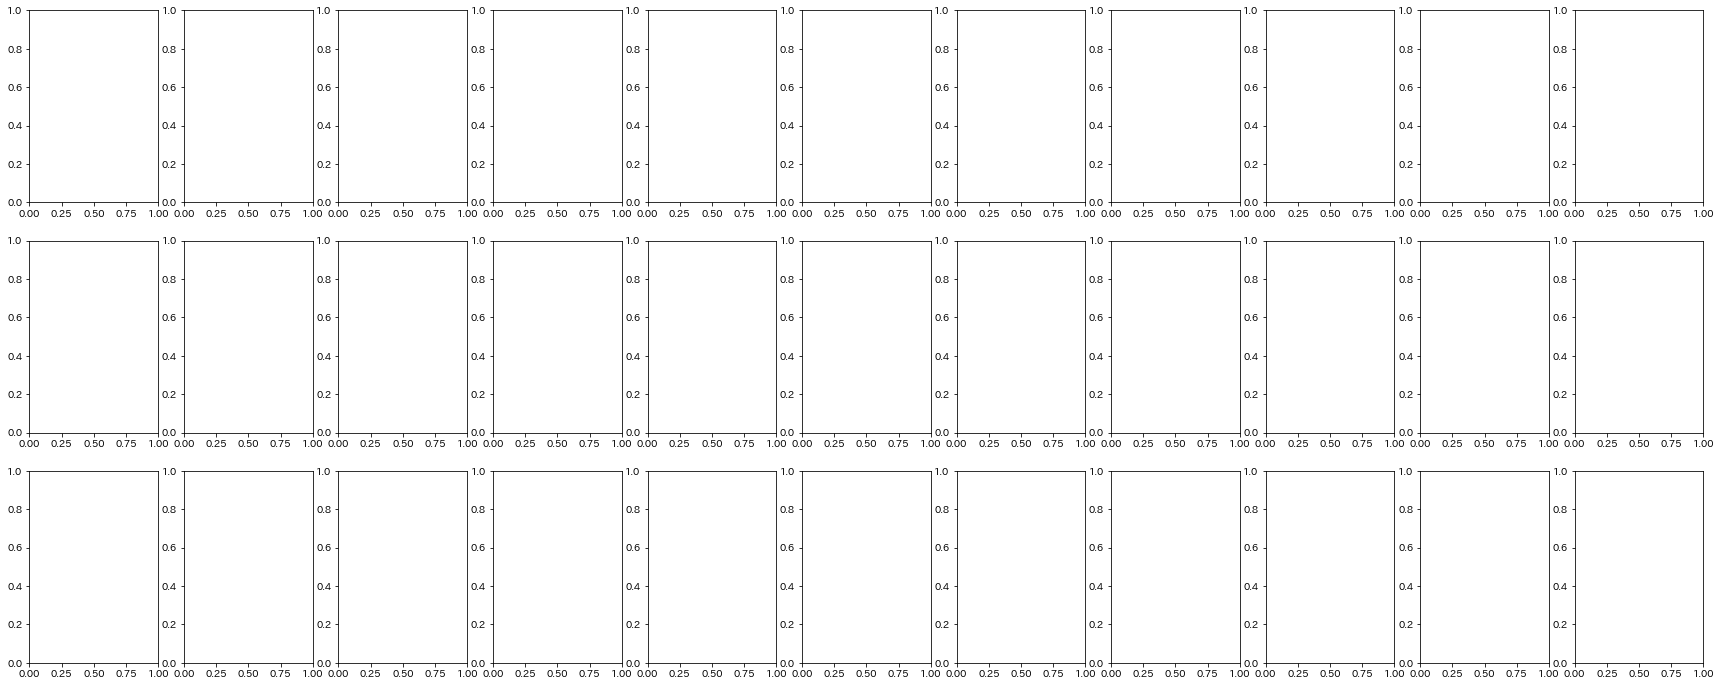

In [5]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Create a figure with subplots for df_hurst, df_alff, and df_reho
fig, axs = plt.subplots(3, 11, figsize=(30, 12))  # 3 rows (one for each DataFrame) and 11 columns (one for each subject)

#dfs = [(df_alff, "ALFF"), (df_reho, "ReHo") ]  # Add (df_alff, "ALFF"), (df_reho, "ReHo") as needed
dfs = [(df_hurst, "Hurst")]
#df_hurst = df_hurst[df_hurst.mean_fd<=0.3]
for i, (df, name) in enumerate(dfs):
    #df = df[df.mean_fd<=0.3]
    df = df[df['type']=='cross']
    # Regressing out 'mean_fd' and 'num_censored_volumes' for all parcels
    X = df[['mean_fd', 'num_censored_volumes']]
    X = sm.add_constant(X)
    p_values = []
    for parcel in range(100):  # For each parcel
        y = df.iloc[:, parcel].values
        model = sm.OLS(y, X).fit()
        df[f'residual_parcel_{parcel}'] = model.resid
        group_non_alcohol = df[df['Alcohol/No Alcohol'] == 'NoAlcohol'][f'residual_parcel_{parcel}']
        group_alcohol = df[df['Alcohol/No Alcohol'] == 'Alcohol'][f'residual_parcel_{parcel}']
        t_stat, p_value = stats.ttest_ind(group_non_alcohol.values, group_alcohol.values)
        p_values.append(p_value)
    index = [i for i in np.arange(df.shape[1]) if 'residual_parcel' in df.columns[i]]
    df['avg'] = df.iloc[:, index].mean(axis=1)
    reject, pvals_corrected, _, _ = multipletests(p_values, method='fdr_bh')
    print(f"{name} - Corrected p-values for parcels:", pvals_corrected)

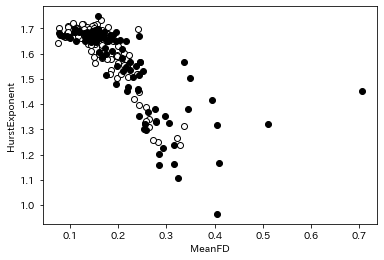

In [6]:
plt.scatter(df[df['Alcohol/No Alcohol']=='NoAlcohol'].mean_fd, df[df['Alcohol/No Alcohol']=='NoAlcohol'].iloc[:, :100].mean(axis=1), color='white', edgecolor='black')
plt.scatter(df[df['Alcohol/No Alcohol']=='Alcohol'].mean_fd, df[df['Alcohol/No Alcohol']=='Alcohol'].iloc[:, :100].mean(axis=1), color='black', edgecolor='black')
plt.xlabel('MeanFD')
plt.ylabel('HurstExponent')
plt.savefig('motion.eps')

In [7]:
no_alcohol_fd = df[df['Alcohol/No Alcohol'] == 'NoAlcohol'].mean_fd
no_alcohol_hurst = df[df['Alcohol/No Alcohol'] == 'NoAlcohol'].iloc[:, :100].mean(axis=1)

alcohol_fd = df[df['Alcohol/No Alcohol'] == 'Alcohol'].mean_fd
alcohol_hurst = df[df['Alcohol/No Alcohol'] == 'Alcohol'].iloc[:, :100].mean(axis=1)

# Calculate correlation coefficient and p-value for No Alcohol condition
corr_no_alcohol, p_val_no_alcohol = stats.pearsonr(no_alcohol_fd, no_alcohol_hurst)

# Calculate correlation coefficient and p-value for Alcohol condition
corr_alcohol, p_val_alcohol = stats.pearsonr(alcohol_fd, alcohol_hurst)

# Print results
print(f'No Alcohol condition: Correlation = {corr_no_alcohol}, P-value = {p_val_no_alcohol}')
print(f'Alcohol condition: Correlation = {corr_alcohol}, P-value = {p_val_alcohol}')

No Alcohol condition: Correlation = -0.8556463847595012, P-value = 1.624009364927561e-31
Alcohol condition: Correlation = -0.717601057131145, P-value = 4.0258675260826686e-16


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


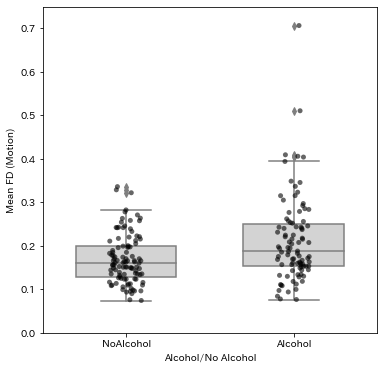

[-3.715638609116162, 0.00026365089893369233]


In [8]:
plt.figure(figsize=(6, 6))
sns.boxplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, color='lightgray', width=0.6)
sns.stripplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, jitter=True, color='black', edgecolor='black', alpha=0.6)
plt.xlabel('Alcohol/No Alcohol')
plt.ylabel('Mean FD (Motion)')
plt.ylim([0, 0.75])
plt.savefig('motion_boxplot_with_scatter.eps')
plt.show()
no_alcohol = df[df['Alcohol/No Alcohol'] == 'NoAlcohol']['mean_fd']
alcohol = df[df['Alcohol/No Alcohol'] == 'Alcohol']['mean_fd']
t_stat, p_value = stats.ttest_ind(no_alcohol, alcohol)
print([t_stat,p_value])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


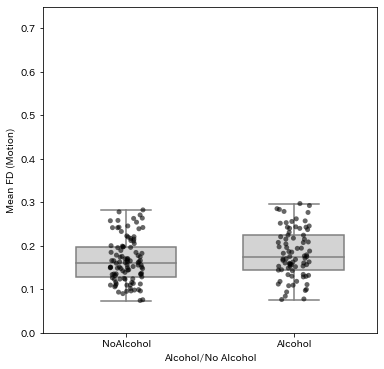

[-2.152601380819222, 0.03266671535282686]


In [9]:
plt.figure(figsize=(6, 6))
df = df[df.mean_fd<0.3]
sns.boxplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, color='lightgray', width=0.6)
sns.stripplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, jitter=True, color='black', edgecolor='black', alpha=0.6)
plt.xlabel('Alcohol/No Alcohol')
plt.ylabel('Mean FD (Motion)')
plt.ylim([0, 0.75])
plt.savefig('motion_boxplot_0.3.eps')
plt.show()
no_alcohol = df[df['Alcohol/No Alcohol'] == 'NoAlcohol']['mean_fd']
alcohol = df[df['Alcohol/No Alcohol'] == 'Alcohol']['mean_fd']
t_stat, p_value = stats.ttest_ind(no_alcohol, alcohol)
print([t_stat,p_value])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


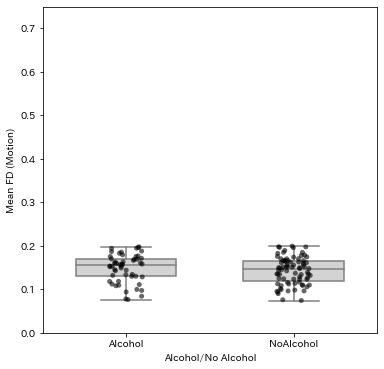

[-0.8762918214165408, 0.3825002721515104]


In [10]:
plt.figure(figsize=(6, 6))
df = df[df.mean_fd<0.2]
sns.boxplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, color='lightgray', width=0.6)
sns.stripplot(x='Alcohol/No Alcohol', y='mean_fd', data=df, jitter=True, color='black', edgecolor='black', alpha=0.6)
plt.xlabel('Alcohol/No Alcohol')
plt.ylabel('Mean FD (Motion)')
plt.ylim([0, 0.75])
plt.savefig('motion_boxplot_0.2.eps')
plt.show()
no_alcohol = df[df['Alcohol/No Alcohol'] == 'NoAlcohol']['mean_fd']
alcohol = df[df['Alcohol/No Alcohol'] == 'Alcohol']['mean_fd']
t_stat, p_value = stats.ttest_ind(no_alcohol, alcohol)
print([t_stat,p_value])